## 1 Identify the obs layout

In [8]:
import numpy as np
import torch
import torch.nn as nn
import gymnasium as gym
import metaworld
from stable_baselines3 import SAC
from scipy.stats import spearmanr

TASK_NAME = "peg-insert-side-v3"
SUCCESS_KEY = "success"

def make_env(seed=0, render_mode=None):
    return gym.make("Meta-World/MT1", env_name=TASK_NAME, seed=seed, render_mode=render_mode)

_probe = make_env(seed=0)
OBS_DIM = _probe.observation_space.shape[0]
DT = getattr(_probe.unwrapped, "dt", _probe.unwrapped.model.opt.timestep)
_probe.close()

device = "cuda" if torch.cuda.is_available() else "cpu"

# Architecture MUST match the saved checkpoint — this is the dropout version
# (the earlier no-dropout definition caused the state_dict key mismatch).
class Time2SuccessModel(nn.Module):
    def __init__(self, obs_dim, hidden=256, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden, hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden, 1),
        )
    def forward(self, x):
        return self.net(x).squeeze(-1)

# --- Load the trained time2success model + its normalization stats ---
norm = np.load("./checkpoints/time2successV4/normalization.npz")
X_MEAN, X_STD = norm["X_mean"], norm["X_std"]
Y_MEAN, Y_STD = norm["y_mean"].item(), norm["y_std"].item()

t2s_model = Time2SuccessModel(obs_dim=OBS_DIM).to(device)
t2s_model.load_state_dict(
    torch.load("./checkpoints/time2successV4/time2success_state_model_best.pt"))
t2s_model.eval()  # disables dropout — important for deterministic predictions

@torch.no_grad()
def predict_t2s(obs):
    """obs (raw, unnormalized) -> predicted steps remaining (real units)."""
    x = torch.tensor((obs - X_MEAN) / X_STD, dtype=torch.float32).unsqueeze(0).to(device)
    pred_norm = t2s_model(x).item()
    return pred_norm * Y_STD + Y_MEAN

print(f"OBS_DIM={OBS_DIM}, device={device}")
print(f"Sanity check — predict_t2s on a reset state: {predict_t2s(make_env(seed=0).reset()[0]):.1f} steps")

OBS_DIM=39, device=cpu
Sanity check — predict_t2s on a reset state: 59.0 steps


d:\Miniconda3\envs\duke_rob\lib\site-packages\gymnasium\utils\passive_env_checker.py:157: UserWarning: WARN: The obs returned by the `reset()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")


In [9]:
import numpy as np
import gymnasium as gym
import metaworld

TASK_NAME = "peg-insert-side-v3"
SUCCESS_KEY = "success"

def make_env(seed=0, render_mode=None):
    return gym.make("Meta-World/MT1", env_name=TASK_NAME, seed=seed, render_mode=render_mode)

env = make_env(seed=0)
obs, _ = env.reset()
print("obs shape:", obs.shape)
print("obs:\n", np.round(obs, 4))

# MetaWorld v2/v3 obs convention (39-dim) is typically:
#   [0:3]   end-effector (hand) xyz
#   [3]     gripper openness
#   [4:11]  object 1 pose (xyz + quaternion)
#   [11:18] object 2 pose (xyz + quaternion)
#   [18:36] PREVIOUS timestep's copy of [0:18]
#   [36:39] goal xyz
# Verify rather than trust this — the checks below confirm it empirically.

# --- Confirm hand indices: take a large action, see which dims move ---
obs_before = obs.copy()
for _ in range(5):
    obs_after, *_ = env.step(np.array([1.0, 0.0, 0.0, 0.0]))  # push +x
delta = np.abs(obs_after - obs_before)
print("\nTop-10 dims changed by a +x arm action:")
for i in np.argsort(delta)[::-1][:10]:
    print(f"  idx {i}: {obs_before[i]:.4f} -> {obs_after[i]:.4f}  (|delta|={delta[i]:.4f})")
env.close()

obs shape: (39,)
obs:
 [ 0.0046  0.6014  0.1951  1.      0.0509  0.5697  0.03    0.      0.
  0.      1.      0.      0.      0.      0.      0.      0.      0.
  0.0046  0.6014  0.1951  1.      0.0509  0.5697  0.03    0.      0.
  0.      1.      0.      0.      0.      0.      0.      0.      0.
 -0.2519  0.5867  0.1304]

Top-10 dims changed by a +x arm action:
  idx 0: 0.0046 -> 0.0254  (|delta|=0.0208)
  idx 18: 0.0046 -> 0.0185  (|delta|=0.0139)
  idx 24: 0.0300 -> 0.0226  (|delta|=0.0074)
  idx 6: 0.0300 -> 0.0227  (|delta|=0.0073)
  idx 1: 0.6014 -> 0.5980  (|delta|=0.0034)
  idx 19: 0.6014 -> 0.5986  (|delta|=0.0028)
  idx 20: 0.1951 -> 0.1950  (|delta|=0.0001)
  idx 2: 0.1951 -> 0.1951  (|delta|=0.0000)
  idx 8: 0.0000 -> 0.0000  (|delta|=0.0000)
  idx 26: 0.0000 -> 0.0000  (|delta|=0.0000)


d:\Miniconda3\envs\duke_rob\lib\site-packages\gymnasium\utils\passive_env_checker.py:157: UserWarning: WARN: The obs returned by the `step()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")


In [10]:
# --- Confirm goal indices: compare across seeds (goal changes, layout doesn't) ---
obs_by_seed = []
for s in [0, 1, 2, 3, 4]:
    e = make_env(seed=s)
    o, _ = e.reset()
    obs_by_seed.append(o)
    e.close()
obs_by_seed = np.array(obs_by_seed)

variance_across_seeds = obs_by_seed.std(axis=0)
print("Dims that vary most across seeds (goal/object placement):")
for i in np.argsort(variance_across_seeds)[::-1][:12]:
    print(f"  idx {i}: std={variance_across_seeds[i]:.4f}, values={np.round(obs_by_seed[:, i], 3)}")

Dims that vary most across seeds (goal/object placement):
  idx 37: std=0.0749, values=[0.587 0.558 0.489 0.653 0.439]
  idx 4: std=0.0375, values=[0.051 0.163 0.103 0.077 0.083]
  idx 22: std=0.0375, values=[0.051 0.163 0.103 0.077 0.083]
  idx 23: std=0.0354, values=[0.57  0.554 0.611 0.533 0.628]
  idx 5: std=0.0354, values=[0.57  0.554 0.611 0.533 0.628]
  idx 36: std=0.0235, values=[-0.252 -0.235 -0.3   -0.277 -0.286]
  idx 38: std=0.0003, values=[0.13  0.131 0.131 0.131 0.13 ]
  idx 24: std=0.0000, values=[0.03 0.03 0.03 0.03 0.03]
  idx 6: std=0.0000, values=[0.03 0.03 0.03 0.03 0.03]
  idx 34: std=0.0000, values=[0. 0. 0. 0. 0.]
  idx 35: std=0.0000, values=[0. 0. 0. 0. 0.]
  idx 32: std=0.0000, values=[0. 0. 0. 0. 0.]


In [11]:
HAND_POS_IDX = [0, 1, 2]      # adjust based on the +x action test above
PEG_POS_IDX  = [4, 5, 6]      # adjust based on the cross-seed variance test
GOAL_POS_IDX = [36, 37, 38]   # adjust based on the cross-seed variance test
print("Hand:", HAND_POS_IDX, "Peg:", PEG_POS_IDX, "Goal:", GOAL_POS_IDX)

Hand: [0, 1, 2] Peg: [4, 5, 6] Goal: [36, 37, 38]


## 2 Perturbation Test

In [12]:
def perturbation_test(predict_fn, n_samples=20, delta=0.1):
    """Does the model respond to peg/goal position, or only to arm position?"""
    results = {"hand": [], "peg": [], "goal": []}

    for seed in range(n_samples):
        e = make_env(seed=seed)
        obs, _ = e.reset()
        e.close()
        base = predict_fn(obs)

        for name, idx in [("hand", HAND_POS_IDX), ("peg", PEG_POS_IDX), ("goal", GOAL_POS_IDX)]:
            perturbed = obs.copy()
            perturbed[idx] = perturbed[idx] + delta  # shift only this component
            results[name].append(abs(predict_fn(perturbed) - base))

    print(f"Mean |prediction change| from a {delta} shift in each component:\n")
    for name in ["hand", "peg", "goal"]:
        vals = np.array(results[name])
        print(f"  {name:5s}: mean={vals.mean():7.3f} steps, std={vals.std():6.3f}, max={vals.max():7.3f}")
    return results

pert = perturbation_test(predict_t2s)

Mean |prediction change| from a 0.1 shift in each component:

  hand : mean= 22.823 steps, std=10.903, max= 56.221
  peg  : mean= 19.289 steps, std=29.558, max=143.705
  goal : mean= 45.650 steps, std=33.485, max=189.054


## 3 Ranking Metric test

In [13]:
from scipy.stats import spearmanr

def ranking_test(predict_fn, policy, n_episodes=15, max_steps=500):
    within_ep_rhos = []
    all_preds, all_actuals = [], []

    for seed in range(500, 500 + n_episodes):  # seeds outside the training collection range
        e = make_env(seed=seed)
        obs, _ = e.reset()
        preds, success_step = [], None
        for t in range(max_steps):
            preds.append(predict_fn(obs))
            action, _ = policy.predict(obs, deterministic=True)
            obs, _, terminated, truncated, info = e.step(action)
            if info.get(SUCCESS_KEY, 0) and success_step is None:
                success_step = t
            if terminated or truncated:
                break
        e.close()

        if success_step is None:
            continue

        actuals = [max(0, success_step - t) for t in range(len(preds))]
        rho, _ = spearmanr(preds, actuals)
        within_ep_rhos.append(rho)
        all_preds.extend(preds)
        all_actuals.extend(actuals)

    global_rho, _ = spearmanr(all_preds, all_actuals)
    print(f"Episodes evaluated: {len(within_ep_rhos)}")
    print(f"Mean within-episode Spearman: {np.mean(within_ep_rhos):.3f} "
          f"(min={np.min(within_ep_rhos):.3f}, max={np.max(within_ep_rhos):.3f})")
    print(f"Global (pooled) Spearman:     {global_rho:.3f}")
    return within_ep_rhos, global_rho

final_policy = SAC.load("./checkpoints/peg_insert_side/sac_peg_insert_final")
ranking_test(predict_t2s, final_policy)

d:\Miniconda3\envs\duke_rob\lib\site-packages\gymnasium\utils\passive_env_checker.py:34: UserWarning: WARN: A Box observation space maximum and minimum values are equal.
  logger.warn("A Box observation space maximum and minimum values are equal.")
d:\Miniconda3\envs\duke_rob\lib\site-packages\gymnasium\utils\passive_env_checker.py:157: UserWarning: WARN: The obs returned by the `reset()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")
d:\Miniconda3\envs\duke_rob\lib\site-packages\gymnasium\utils\passive_env_checker.py:157: UserWarning: WARN: The obs returned by the `step()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")


Episodes evaluated: 15
Mean within-episode Spearman: 0.525 (min=0.476, max=0.580)
Global (pooled) Spearman:     0.525


([np.float64(0.5062837478064383),
  np.float64(0.5475159167501127),
  np.float64(0.5430538911621839),
  np.float64(0.5297564281575645),
  np.float64(0.5473812571125432),
  np.float64(0.5517512239908863),
  np.float64(0.4913757191701624),
  np.float64(0.5111114491819684),
  np.float64(0.5804463422701992),
  np.float64(0.5139872716280792),
  np.float64(0.5387177323651468),
  np.float64(0.5225482679135282),
  np.float64(0.5013812299532828),
  np.float64(0.475794027270271),
  np.float64(0.5108032147425999)],
 np.float64(0.5251549875671213))

## 4 Decosove Diagnostic

In [14]:
from scipy.stats import spearmanr
import numpy as np

# Load the dataset the model was actually trained on
DATASET_PATH = "./data/state_space_datasetV4/dataset.npz"  # confirm this is the right version
data = np.load(DATASET_PATH)
X = data["X"]
y_steps = data["y_steps"]
episode_ids = data["episode_ids"]

print(f"Loaded {X.shape[0]} rows from {len(np.unique(episode_ids))} episodes")

# Predict on every row, in batches (much faster than one at a time)
@torch.no_grad()
def predict_batch(X_raw, batch_size=1024):
    preds = []
    for i in range(0, len(X_raw), batch_size):
        chunk = X_raw[i:i+batch_size]
        x = torch.tensor((chunk - X_MEAN) / X_STD, dtype=torch.float32).to(device)
        pred_norm = t2s_model(x).cpu().numpy()
        preds.append(pred_norm * Y_STD + Y_MEAN)
    return np.concatenate(preds)

all_preds = predict_batch(X)

Loaded 60000 rows from 120 episodes


In [16]:
# --- Per-episode Spearman on the TRAINING data ---
per_ep_rhos = []
for ep_id in np.unique(episode_ids):
    mask = episode_ids == ep_id
    ep_preds = all_preds[mask]
    ep_actuals = y_steps[mask]

    # Skip episodes where the label is constant (all post-success zeros)
    if np.std(ep_actuals) < 1e-6:
        continue
    rho, _ = spearmanr(ep_preds, ep_actuals)
    per_ep_rhos.append(rho)

per_ep_rhos = np.array(per_ep_rhos)
global_rho, _ = spearmanr(all_preds, y_steps)

print(f"Episodes with label variation: {len(per_ep_rhos)}")
print(f"TRAINING-set mean within-episode Spearman: {per_ep_rhos.mean():.3f} "
      f"(min={per_ep_rhos.min():.3f}, max={per_ep_rhos.max():.3f})")
print(f"TRAINING-set global Spearman: {global_rho:.3f}")
print(f"\nCompare against held-out (step 3): ~0.525")

# --- Same test, but ONLY the pre-success portion of each episode ---
pre_success_rhos = []
for ep_id in np.unique(episode_ids):
    mask = episode_ids == ep_id
    ep_preds = all_preds[mask]
    ep_actuals = y_steps[mask]

    # Keep only frames before success (label > 0)
    nonzero = ep_actuals > 0
    if nonzero.sum() < 10:
        continue
    rho, _ = spearmanr(ep_preds[nonzero], ep_actuals[nonzero])
    pre_success_rhos.append(rho)

pre_success_rhos = np.array(pre_success_rhos)
print(f"TRAINING-set, PRE-SUCCESS ONLY, mean Spearman: {pre_success_rhos.mean():.3f} "
      f"(min={pre_success_rhos.min():.3f}, max={pre_success_rhos.max():.3f})")

Episodes with label variation: 120
TRAINING-set mean within-episode Spearman: 0.587 (min=0.476, max=0.929)
TRAINING-set global Spearman: 0.604

Compare against held-out (step 3): ~0.525
TRAINING-set, PRE-SUCCESS ONLY, mean Spearman: 0.988 (min=0.549, max=1.000)


In [17]:
def ranking_test_pre_success(predict_fn, policy, n_episodes=15, max_steps=500):
    rhos = []
    for seed in range(500, 500 + n_episodes):
        e = make_env(seed=seed)
        obs, _ = e.reset()
        preds, success_step = [], None
        for t in range(max_steps):
            preds.append(predict_fn(obs))
            action, _ = policy.predict(obs, deterministic=True)
            obs, _, terminated, truncated, info = e.step(action)
            if info.get(SUCCESS_KEY, 0) and success_step is None:
                success_step = t
                break          # stop at success — only the graded region
            if terminated or truncated:
                break
        e.close()
        if success_step is None or len(preds) < 10:
            continue
        actuals = [success_step - t for t in range(len(preds))]
        rho, _ = spearmanr(preds, actuals)
        rhos.append(rho)
    rhos = np.array(rhos)
    print(f"HELD-OUT, pre-success only: mean Spearman={rhos.mean():.3f} "
          f"(min={rhos.min():.3f}, max={rhos.max():.3f}, n={len(rhos)})")
    return rhos

ranking_test_pre_success(predict_t2s, final_policy)

HELD-OUT, pre-success only: mean Spearman=0.830 (min=-0.245, max=1.000, n=15)


array([ 1.        ,  1.        ,  0.9557758 ,  0.98500242,  0.95022038,
        0.97920576,  1.        ,  0.99867347,  0.99361888,  0.02434574,
        0.98059163, -0.24519764,  0.99745606,  1.        ,  0.83122449])

## Check failure seeds

In [18]:
import matplotlib.pyplot as plt

BAD_SEEDS = [509, 511]                    # rho = 0.024 and -0.245
GOOD_SEEDS = [500, 501, 506, 513]         # rho = 1.00 for comparison

def collect_trace(seed, policy, max_steps=500):
    """Roll out one episode, capturing predictions + the obs indices we care about."""
    e = make_env(seed=seed)
    obs, _ = e.reset()
    preds, hand_pos, peg_pos, goal_pos = [], [], [], []
    success_step = None
    for t in range(max_steps):
        preds.append(predict_t2s(obs))
        hand_pos.append(obs[HAND_POS_IDX].copy())
        peg_pos.append(obs[PEG_POS_IDX].copy())
        goal_pos.append(obs[GOAL_POS_IDX].copy())
        action, _ = policy.predict(obs, deterministic=True)
        obs, _, terminated, truncated, info = e.step(action)
        if info.get(SUCCESS_KEY, 0) and success_step is None:
            success_step = t
            break
        if terminated or truncated:
            break
    e.close()
    return dict(seed=seed, preds=np.array(preds), success_step=success_step,
                hand=np.array(hand_pos), peg=np.array(peg_pos), goal=np.array(goal_pos))

bad_traces = [collect_trace(s, final_policy) for s in BAD_SEEDS]
good_traces = [collect_trace(s, final_policy) for s in GOOD_SEEDS]

for tr in bad_traces + good_traces:
    print(f"seed {tr['seed']}: success_step={tr['success_step']}, "
          f"peg={np.round(tr['peg'][0], 3)}, goal={np.round(tr['goal'][0], 3)}")

d:\Miniconda3\envs\duke_rob\lib\site-packages\gymnasium\utils\passive_env_checker.py:34: UserWarning: WARN: A Box observation space maximum and minimum values are equal.
  logger.warn("A Box observation space maximum and minimum values are equal.")
d:\Miniconda3\envs\duke_rob\lib\site-packages\gymnasium\utils\passive_env_checker.py:157: UserWarning: WARN: The obs returned by the `reset()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")
d:\Miniconda3\envs\duke_rob\lib\site-packages\gymnasium\utils\passive_env_checker.py:157: UserWarning: WARN: The obs returned by the `step()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")


seed 509: success_step=49, peg=[0.116 0.58  0.03 ], goal=[-0.285  0.62   0.13 ]
seed 511: success_step=51, peg=[0.127 0.546 0.03 ], goal=[-0.306  0.558  0.13 ]
seed 500: success_step=47, peg=[0.093 0.564 0.03 ], goal=[-0.299  0.668  0.13 ]
seed 501: success_step=56, peg=[0.187 0.683 0.03 ], goal=[-0.273  0.586  0.131]
seed 506: success_step=44, peg=[0.174 0.616 0.03 ], goal=[-0.23   0.428  0.13 ]
seed 513: success_step=41, peg=[0.125 0.591 0.03 ], goal=[-0.233  0.447  0.13 ]


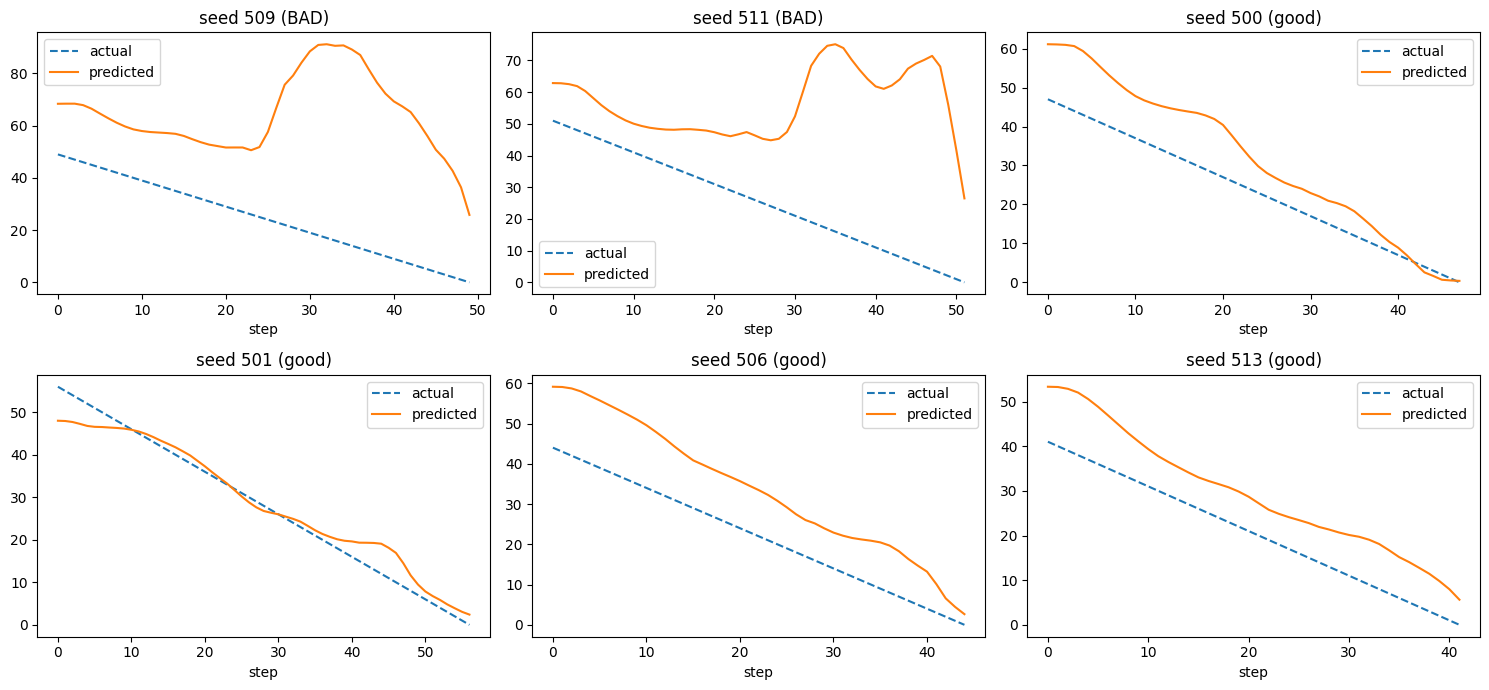

In [19]:
# --- Predicted vs actual, bad seeds next to good ones ---
fig, axes = plt.subplots(2, 3, figsize=(15, 7))

for ax, tr in zip(axes[0], bad_traces + [good_traces[0]]):
    actual = [tr["success_step"] - t for t in range(len(tr["preds"]))]
    ax.plot(actual, "--", label="actual")
    ax.plot(tr["preds"], label="predicted")
    ax.set_title(f"seed {tr['seed']} (BAD)" if tr["seed"] in BAD_SEEDS else f"seed {tr['seed']} (good)")
    ax.set_xlabel("step"); ax.legend()

for ax, tr in zip(axes[1], good_traces[1:4]):
    actual = [tr["success_step"] - t for t in range(len(tr["preds"]))]
    ax.plot(actual, "--", label="actual")
    ax.plot(tr["preds"], label="predicted")
    ax.set_title(f"seed {tr['seed']} (good)")
    ax.set_xlabel("step"); ax.legend()

plt.tight_layout(); plt.show()

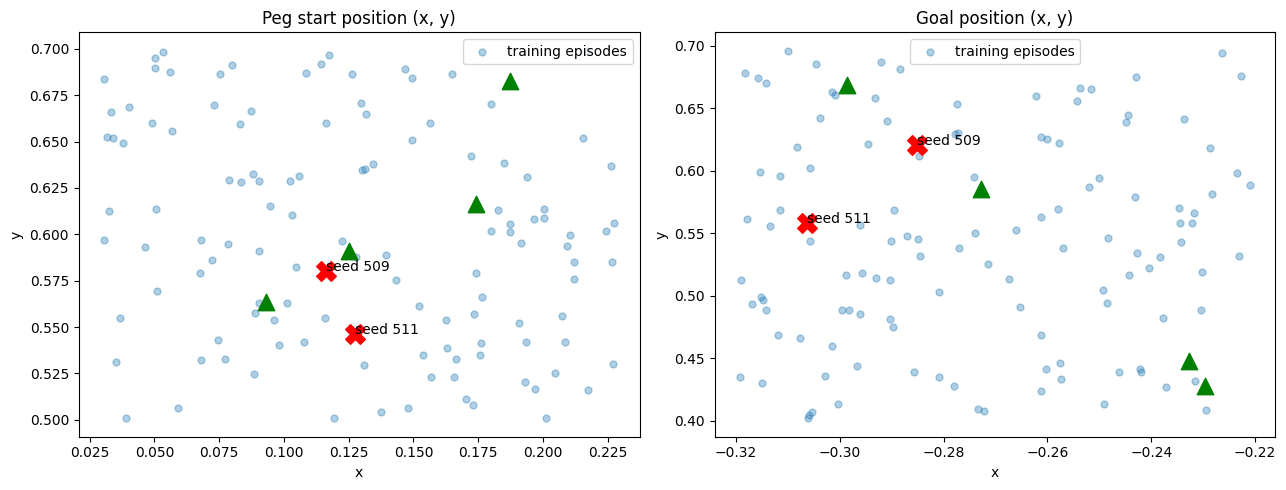

In [20]:
# --- Where do the bad seeds sit in peg/goal space, relative to training data? ---
train_data = np.load("./data/state_space_datasetV4/dataset.npz")
X_train_all = train_data["X"]
ep_ids = train_data["episode_ids"]

# One starting state per training episode
first_rows = np.array([np.where(ep_ids == e)[0][0] for e in np.unique(ep_ids)])
train_peg = X_train_all[first_rows][:, PEG_POS_IDX]
train_goal = X_train_all[first_rows][:, GOAL_POS_IDX]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(train_peg[:, 0], train_peg[:, 1], alpha=0.35, s=25, label="training episodes")
for tr in good_traces:
    axes[0].scatter(*tr["peg"][0][:2], marker="^", s=140, c="green")
for tr in bad_traces:
    axes[0].scatter(*tr["peg"][0][:2], marker="X", s=200, c="red")
    axes[0].annotate(f"seed {tr['seed']}", tr["peg"][0][:2])
axes[0].set_title("Peg start position (x, y)"); axes[0].set_xlabel("x"); axes[0].set_ylabel("y")
axes[0].legend()

axes[1].scatter(train_goal[:, 0], train_goal[:, 1], alpha=0.35, s=25, label="training episodes")
for tr in good_traces:
    axes[1].scatter(*tr["goal"][0][:2], marker="^", s=140, c="green")
for tr in bad_traces:
    axes[1].scatter(*tr["goal"][0][:2], marker="X", s=200, c="red")
    axes[1].annotate(f"seed {tr['seed']}", tr["goal"][0][:2])
axes[1].set_title("Goal position (x, y)"); axes[1].set_xlabel("x"); axes[1].set_ylabel("y")
axes[1].legend()

plt.tight_layout(); plt.show()

In [21]:
import imageio
from IPython.display import Video

def record_with_predictions(seed, policy, out_path, max_steps=500):
    """Records a rollout and returns predictions alongside, so video and curve line up frame-for-frame."""
    e = make_env(seed=seed, render_mode="rgb_array")
    obs, _ = e.reset()
    frames, preds = [], []
    success_step = None
    for t in range(max_steps):
        frames.append(e.render())
        preds.append(predict_t2s(obs))
        action, _ = policy.predict(obs, deterministic=True)
        obs, _, terminated, truncated, info = e.step(action)
        if info.get(SUCCESS_KEY, 0) and success_step is None:
            success_step = t
            # keep a short tail so you can see the completed state
            for _ in range(20):
                frames.append(e.render())
                preds.append(predict_t2s(obs))
                action, _ = policy.predict(obs, deterministic=True)
                obs, *_ = e.step(action)
            break
        if terminated or truncated:
            break
    e.close()
    imageio.mimsave(out_path, frames, fps=20)
    print(f"seed {seed}: saved {out_path}, success_step={success_step}, {len(frames)} frames")
    return np.array(preds), success_step

preds_511, succ_511 = record_with_predictions(511, final_policy, "bad_seed_511.mp4")
preds_509, succ_509 = record_with_predictions(509, final_policy, "bad_seed_509.mp4")
preds_500, succ_500 = record_with_predictions(500, final_policy, "good_seed_500.mp4")

seed 511: saved bad_seed_511.mp4, success_step=51, 72 frames
seed 509: saved bad_seed_509.mp4, success_step=49, 70 frames
seed 500: saved good_seed_500.mp4, success_step=47, 68 frames


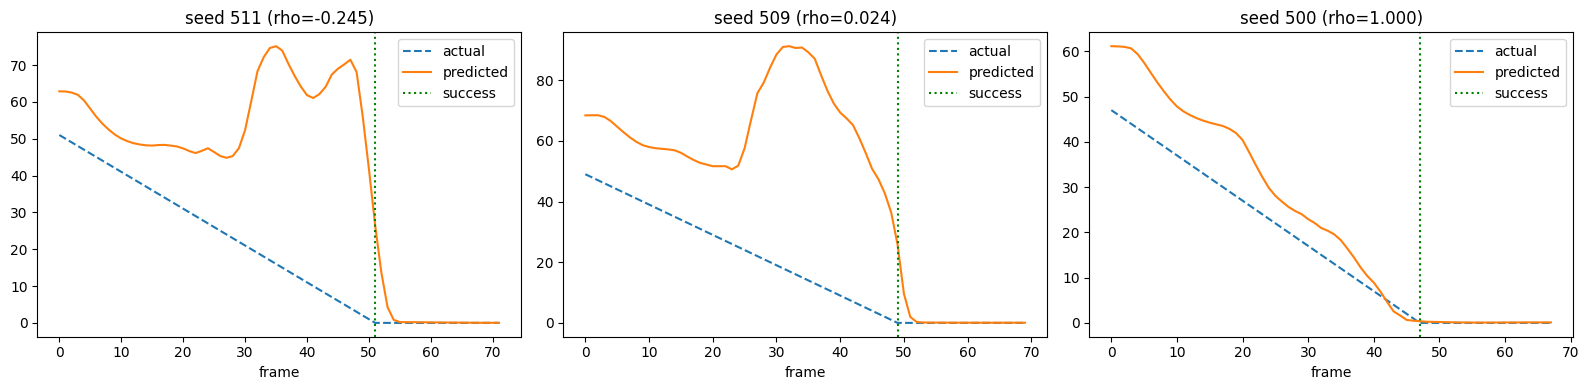

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (preds, succ, seed, rho) in zip(axes, [
    (preds_511, succ_511, 511, -0.245),
    (preds_509, succ_509, 509, 0.024),
    (preds_500, succ_500, 500, 1.000),
]):
    actual = [max(0, succ - t) for t in range(len(preds))]
    ax.plot(actual, "--", label="actual")
    ax.plot(preds, label="predicted")
    ax.axvline(succ, color="green", ls=":", label="success")
    ax.set_title(f"seed {seed} (rho={rho:.3f})")
    ax.set_xlabel("frame"); ax.legend()
plt.tight_layout(); plt.show()

## Grab Feedback Test

In [23]:
import matplotlib.pyplot as plt
import numpy as np

# GRIPPER_IDX: idx 3 was 1.0 at reset in your step-1 output — likely gripper openness.
# Verify it moves when you command the gripper before trusting it.
GRIPPER_IDX = 3

def collect_trace_full(seed, policy, max_steps=500):
    e = make_env(seed=seed)
    obs, _ = e.reset()
    rec = dict(preds=[], hand=[], peg=[], goal=[], gripper=[])
    success_step = None
    for t in range(max_steps):
        rec["preds"].append(predict_t2s(obs))
        rec["hand"].append(obs[HAND_POS_IDX].copy())
        rec["peg"].append(obs[PEG_POS_IDX].copy())
        rec["goal"].append(obs[GOAL_POS_IDX].copy())
        rec["gripper"].append(obs[GRIPPER_IDX])
        action, _ = policy.predict(obs, deterministic=True)
        obs, _, terminated, truncated, info = e.step(action)
        if info.get(SUCCESS_KEY, 0) and success_step is None:
            success_step = t
            break
        if terminated or truncated:
            break
    e.close()
    for k in rec:
        rec[k] = np.array(rec[k])
    rec["seed"] = seed
    rec["success_step"] = success_step
    # Derived geometry the model must infer rather than being given
    rec["hand_to_peg"] = np.linalg.norm(rec["hand"] - rec["peg"], axis=1)
    rec["peg_to_goal"] = np.linalg.norm(rec["peg"] - rec["goal"], axis=1)
    return rec

traces = {s: collect_trace_full(s, final_policy) for s in [511, 509, 500, 501]}

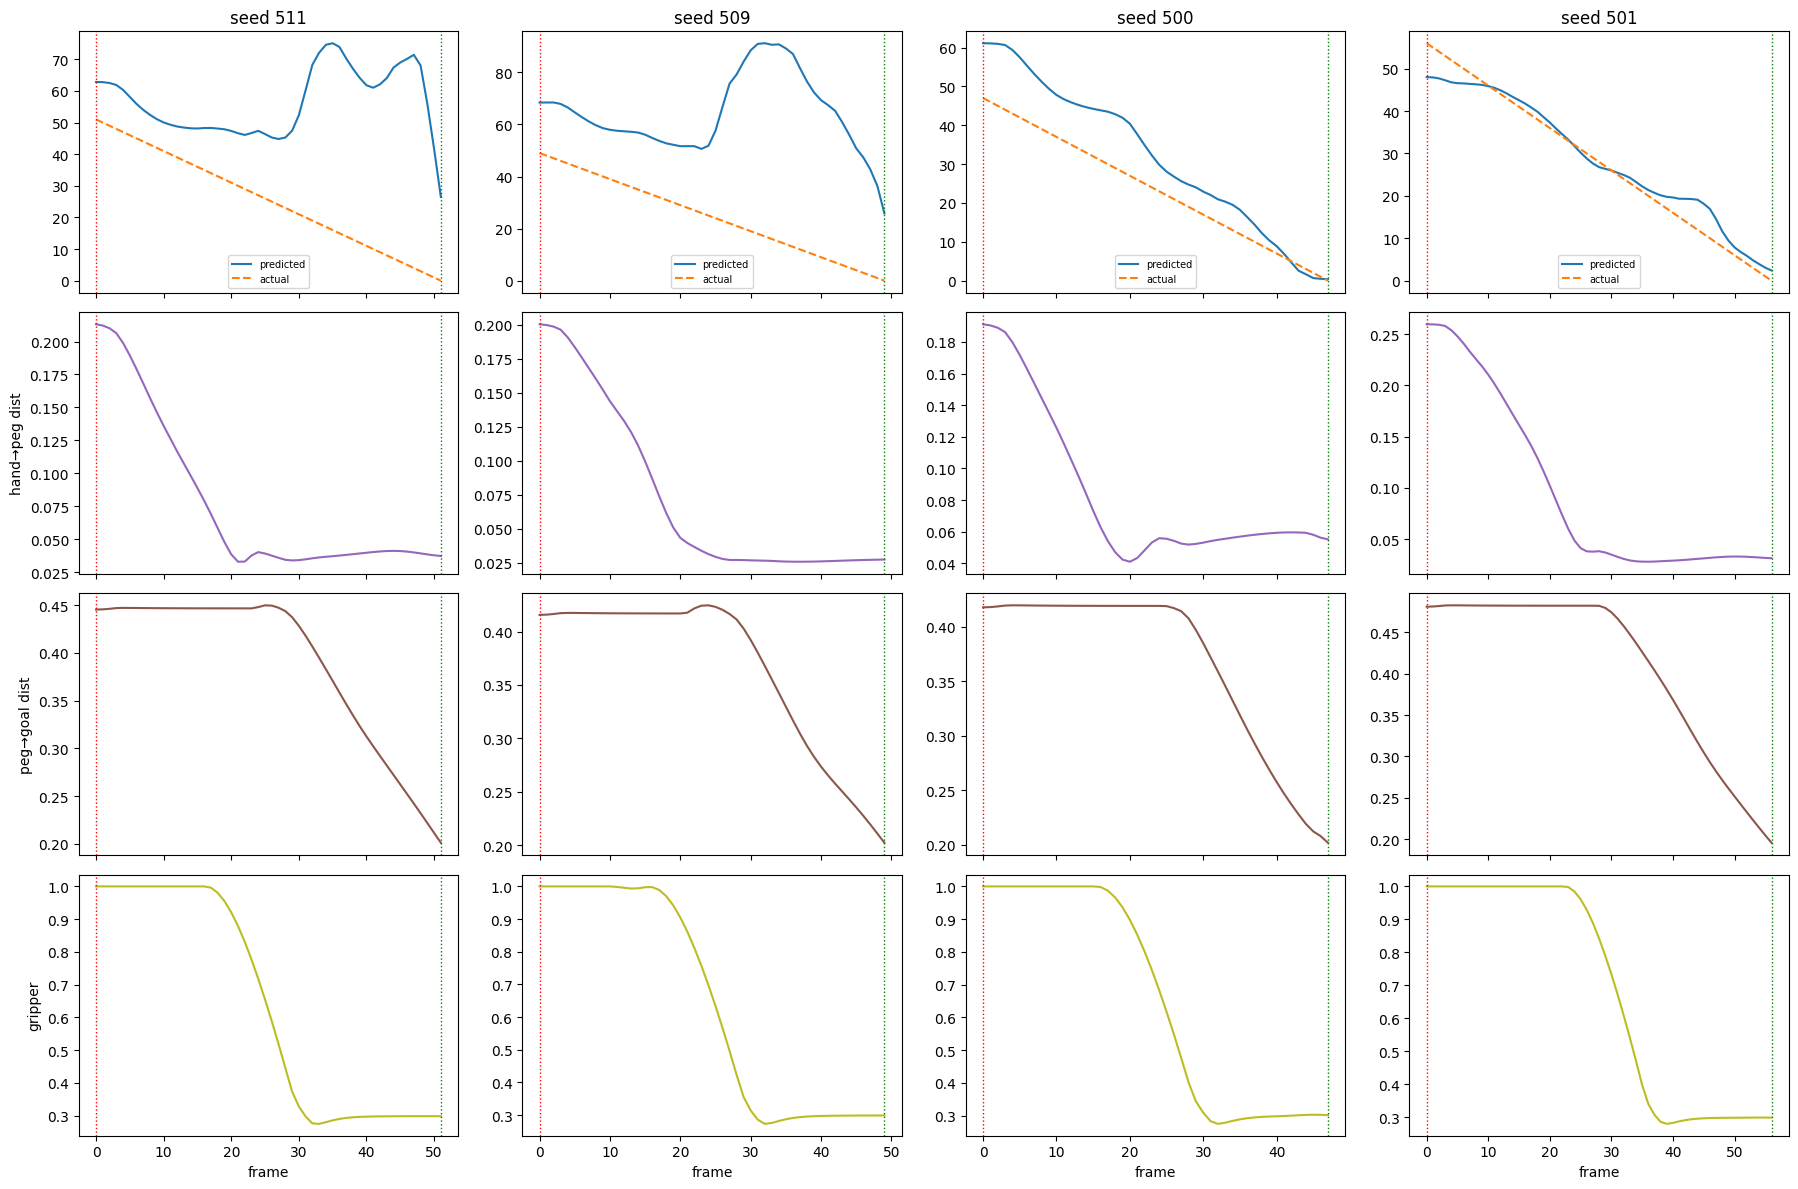

In [24]:
fig, axes = plt.subplots(4, 4, figsize=(18, 12), sharex="col")

for col, seed in enumerate([511, 509, 500, 501]):
    tr = traces[seed]
    n = len(tr["preds"])
    succ = tr["success_step"]

    axes[0, col].plot(tr["preds"], label="predicted")
    axes[0, col].plot([max(0, succ - t) for t in range(n)], "--", label="actual")
    axes[0, col].set_title(f"seed {seed}")
    axes[0, col].legend(fontsize=7)

    axes[1, col].plot(tr["hand_to_peg"], color="tab:purple")
    axes[1, col].set_ylabel("hand→peg dist" if col == 0 else "")

    axes[2, col].plot(tr["peg_to_goal"], color="tab:brown")
    axes[2, col].set_ylabel("peg→goal dist" if col == 0 else "")

    axes[3, col].plot(tr["gripper"], color="tab:olive")
    axes[3, col].set_ylabel("gripper" if col == 0 else "")
    axes[3, col].set_xlabel("frame")

    # mark where the peg first starts moving — a proxy for "grasp happened"
    peg_motion = np.linalg.norm(np.diff(tr["peg"], axis=0), axis=1)
    moved = np.where(peg_motion > 1e-4)[0]
    grasp_frame = moved[0] if len(moved) else None
    for r in range(4):
        if grasp_frame is not None:
            axes[r, col].axvline(grasp_frame, color="red", ls=":", lw=1)
        axes[r, col].axvline(succ, color="green", ls=":", lw=1)

plt.tight_layout(); plt.show()

In [25]:
for seed, tr in traces.items():
    peg_motion = np.linalg.norm(np.diff(tr["peg"], axis=0), axis=1)
    moved = np.where(peg_motion > 1e-4)[0]
    grasp = moved[0] if len(moved) else None
    g = tr["gripper"]
    print(f"seed {seed}: grasp≈{grasp}, gripper range {g.min():.3f}–{g.max():.3f}, "
          f"unique values: {len(np.unique(np.round(g, 3)))}")
    if grasp is not None and grasp + 3 < len(g):
        print(f"   gripper around grasp: {np.round(g[max(0,grasp-3):grasp+4], 3)}")

seed 511: grasp≈0, gripper range 0.275–1.000, unique values: 26
   gripper around grasp: [1. 1. 1. 1.]
seed 509: grasp≈0, gripper range 0.273–1.000, unique values: 29
   gripper around grasp: [1. 1. 1. 1.]
seed 500: grasp≈0, gripper range 0.275–1.000, unique values: 30
   gripper around grasp: [1. 1. 1. 1.]
seed 501: grasp≈0, gripper range 0.280–1.000, unique values: 26
   gripper around grasp: [1. 1. 1. 1.]


In [26]:
# Does the model itself distinguish "peg held" from "peg not held" at the same hand position?
tr = traces[511]
peg_motion = np.linalg.norm(np.diff(tr["peg"], axis=0), axis=1)
moved = np.where(peg_motion > 1e-4)[0]
grasp = moved[0]

pre_idx = max(0, grasp - 5)
post_idx = min(len(tr["preds"]) - 1, grasp + 5)
print(f"pred just before grasp (frame {pre_idx}): {tr['preds'][pre_idx]:.1f}")
print(f"pred just after grasp  (frame {post_idx}): {tr['preds'][post_idx]:.1f}")
print(f"hand moved {np.linalg.norm(tr['hand'][post_idx] - tr['hand'][pre_idx]):.4f} in that span")

pred just before grasp (frame 0): 62.9
pred just after grasp  (frame 5): 58.1
hand moved 0.0350 in that span


## 5. Ensemble uncertainty — the decisive diagnostic

Run the ensemble training cell in `train_validate_time2success.ipynb` first,
so `./checkpoints/time2success_ensemble/` exists with 5 members.

**What this decides:**
- std spikes on 511/509 where the bump was, stays low on 500/501
  → confirms "model is underdetermined in the gaps"; the uncertainty
  penalty is usable, proceed to the RL wrapper change.
- std uniformly LOW everywhere, including the bad seeds
  → all 5 members learned the same wrong thing. Ensembling won't help;
  go collect failure trajectories instead.

In [27]:
# --- Load the ensemble (replaces the single-model load in cell 1) ---
ENSEMBLE_DIR = "./checkpoints/time2success_ensemble"

norm = np.load(f"{ENSEMBLE_DIR}/normalization.npz")
X_MEAN, X_STD = norm["X_mean"], norm["X_std"]
Y_MEAN, Y_STD = norm["y_mean"].item(), norm["y_std"].item()

ensemble = []
for i in range(5):
    m = Time2SuccessModel(obs_dim=OBS_DIM, dropout=0.2).to(device)
    m.load_state_dict(torch.load(f"{ENSEMBLE_DIR}/model_{i}.pt"))
    m.eval()          # disables dropout — disagreement must come from
                      # different training runs, NOT from random dropout masks
    ensemble.append(m)

@torch.no_grad()
def predict_t2s_ensemble(obs):
    """Returns (mean, std) in real step units."""
    x = torch.tensor((obs - X_MEAN) / X_STD, dtype=torch.float32).unsqueeze(0).to(device)
    preds = np.array([m(x).item() for m in ensemble]) * Y_STD + Y_MEAN
    return preds.mean(), preds.std()

# Rebinding predict_t2s to the ensemble mean keeps EVERY existing cell above
# working unchanged (perturbation test, ranking tests, collect_trace, etc.).
def predict_t2s(obs):
    return predict_t2s_ensemble(obs)[0]

_m, _s = predict_t2s_ensemble(make_env(seed=0).reset()[0])
print(f"Sanity check — ensemble at a reset state: mean={_m:.1f}, std={_s:.1f} steps")

Sanity check — ensemble at a reset state: mean=57.9, std=3.9 steps


In [28]:
# --- Re-collect traces, now capturing per-step ensemble std ---
def collect_trace_ensemble(seed, policy, max_steps=500):
    e = make_env(seed=seed)
    obs, _ = e.reset()
    rec = dict(preds=[], stds=[])
    success_step = None
    for t in range(max_steps):
        m, s = predict_t2s_ensemble(obs)
        rec["preds"].append(m)
        rec["stds"].append(s)
        action, _ = policy.predict(obs, deterministic=True)
        obs, _, terminated, truncated, info = e.step(action)
        if info.get(SUCCESS_KEY, 0) and success_step is None:
            success_step = t
            break
        if terminated or truncated:
            break
    e.close()
    rec["preds"] = np.array(rec["preds"])
    rec["stds"] = np.array(rec["stds"])
    rec["seed"] = seed
    rec["success_step"] = success_step
    return rec

ens_traces = {s: collect_trace_ensemble(s, final_policy) for s in [511, 509, 500, 501]}

for s, tr in ens_traces.items():
    tag = "BAD " if s in (511, 509) else "good"
    print(f"{tag} seed {s}: mean std={tr['stds'].mean():6.2f}, "
          f"max std={tr['stds'].max():6.2f}, success_step={tr['success_step']}")

BAD  seed 511: mean std=  6.53, max std= 10.46, success_step=51
BAD  seed 509: mean std=  9.08, max std= 12.06, success_step=49
good seed 500: mean std=  2.84, max std=  4.99, success_step=47
good seed 501: mean std=  1.97, max std=  2.89, success_step=56


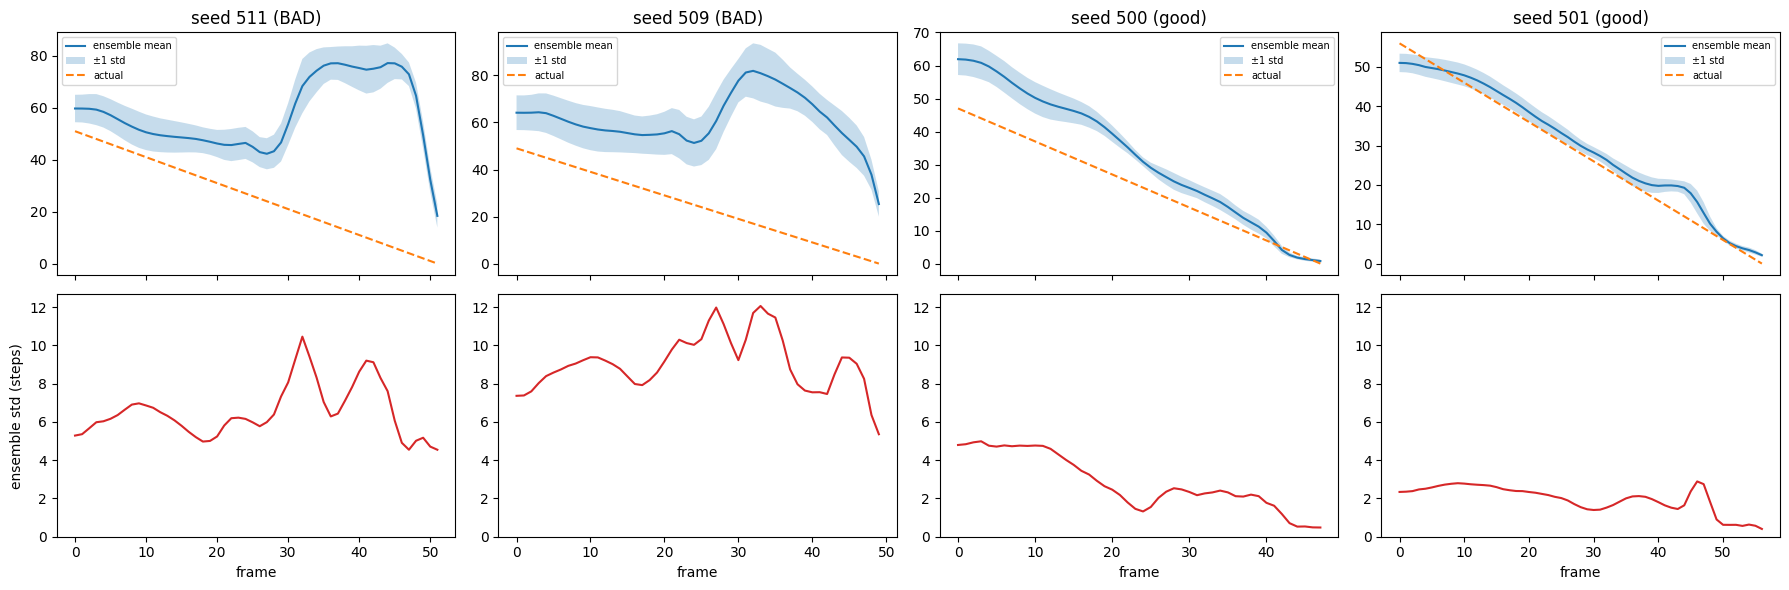

In [29]:
fig, axes = plt.subplots(2, 4, figsize=(18, 6), sharex="col")

for col, seed in enumerate([511, 509, 500, 501]):
    tr = ens_traces[seed]
    succ = tr["success_step"]
    n = len(tr["preds"])
    tag = "BAD" if seed in (511, 509) else "good"

    axes[0, col].plot(tr["preds"], label="ensemble mean")
    axes[0, col].fill_between(range(n),
                                tr["preds"] - tr["stds"],
                                tr["preds"] + tr["stds"],
                                alpha=0.25, label="±1 std")
    axes[0, col].plot([max(0, succ - t) for t in range(n)], "--", label="actual")
    axes[0, col].set_title(f"seed {seed} ({tag})")
    axes[0, col].legend(fontsize=7)

    axes[1, col].plot(tr["stds"], color="tab:red")
    axes[1, col].set_ylabel("ensemble std (steps)" if col == 0 else "")
    axes[1, col].set_xlabel("frame")

# shared y-limit on the std row so the four panels are directly comparable
std_max = max(tr["stds"].max() for tr in ens_traces.values())
for col in range(4):
    axes[1, col].set_ylim(0, std_max * 1.05)

plt.tight_layout(); plt.show()

### If the diagnostic confirms — the RL wrapper change

Only make this edit in `PolicyTrainNew` **after** the std plot above shows
disagreement concentrated on the bad seeds. In
`PureTime2SuccessRewardWrapper._potential`, replace the single-model call:

```python
mean_p, std_p = predict_t2s_ensemble(obs)
pred_steps = float(np.clip(mean_p + self.uncertainty_weight * std_p,
                            0, self.max_pred_steps))
return -pred_steps
```

with `uncertainty_weight` as a new constructor argument (start around 1.0 and
calibrate against the std magnitudes printed above — if typical std is
~2 steps and predictions are ~50, a weight of 1.0 is a mild nudge; if std
reaches 30+ in bad regions, it becomes a strong deterrent, which is the
intent).

Note the wrapper must then hold the whole ensemble, not one model, so the
constructor and `make_pure_t2s_env` need updating to pass the list.